In [2]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 
from meep import mpb
from scipy.optimize import minimize
import utils as u

%matplotlib inline 

In [3]:
import pandas as pd

def read_csv_pandas(filename):
    try:
        df = pd.read_csv(filename)
        return df
    except FileNotFoundError:
        print(f"Error: The file {filename} was not found.")

In [4]:
data1 = read_csv_pandas('Results3/Resolution_64/NumMirrors_1/mode_data.csv')
print(data1)

    Mode  Frequency_THz       Q_Factor  Wavelength_nm
0      1      74.835503    -162.198104    4008.792471
1      2      92.994384     348.524161    3226.001275
2      3     107.080908   21910.230601    2801.619864
3      4     120.022762  -28766.806678    2499.525879
4      5     132.539721  -59794.513928    2263.472394
5      6     144.471382  113452.395460    2076.535818
6      7     155.237074  566752.580249    1932.528048
7      8     163.162669 -280165.878531    1838.655875
8      9     168.597235  -21093.449053    1779.388611
9     10     212.193291     229.628714    1413.805302
10    11     244.797148     975.022260    1225.504471
11    12     252.728309   -6046.328214    1187.045492
12    13     261.096201     118.059575    1149.001783
13    14     268.481444     177.478260    1117.395658
14    15     276.309447     114.428409    1085.739209
15    16     283.786264      60.568926    1057.133619
16    17     295.075752     104.342986    1016.688080


[236774.6278617262, 1262078.2465606325, 450563.95089029387, 179066.93500382733, 209982.85117316063, 198835.8603926558, 121982.58453748532, 500939.3246723844, 86322.62544430216, 6217998.154412723, 1110172.0862558046, 314902.90804633714]
0    -8.077316e+01
1     1.025790e+03
2     5.064611e+03
3     1.519626e+03
4    -6.388197e+03
5    -1.352975e+04
6    -9.221331e+03
7     1.662106e+04
8    -2.827673e+04
9    -6.610572e+04
10   -8.281337e+04
11   -2.559814e+05
12    1.170274e+06
13   -1.317010e+07
14   -6.527579e+05
15    4.544817e+04
16   -7.916521e+03
17    6.819279e+02
18    1.086276e+02
19    1.109816e+02
20    3.530099e+02
21    7.325540e+02
22   -5.980052e+02
23    1.309959e+02
24    6.804139e+02
25    6.434958e+01
26    1.223378e+03
27    1.886684e+03
28    1.858958e+02
29   -1.308319e+02
30    7.105925e+01
31    6.668114e+01
32    9.415225e+01
Name: Q_Factor, dtype: float64


Text(0, 0.5, 'Q Factor')

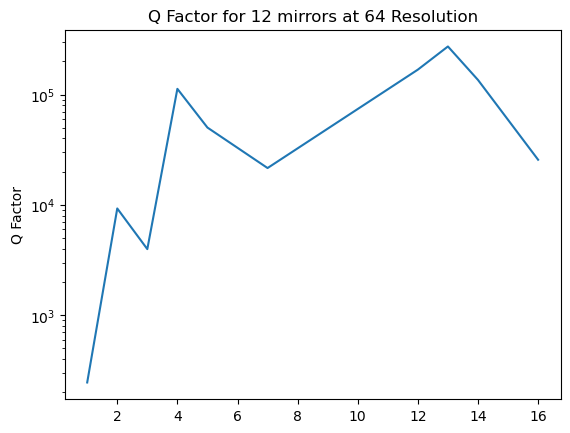

In [5]:
data1['Q_Factor']
max(data1['Q_Factor'])
res = [64, 128, 256]
mirrors = range(1,13)

for i in res: 
    for j in mirrors: 
        globals()[f'data_{i}_{j}'] = read_csv_pandas(f'Results3/Resolution_{i}/NumMirrors_{j}/mode_data.csv')
maxQ64 = []
maxQs128 =[]
maxQs256 = []
for j in mirrors: 
    maxQ64.append(max(globals()[f'data_64_{j}']['Q_Factor']))
    maxQs128.append(max(globals()[f'data_128_{j}']['Q_Factor']))
    maxQs256.append(max(globals()[f'data_256_{j}']['Q_Factor']))
print(maxQs256)
print(data_128_12['Q_Factor'])
plt.semilogy(data_64_12[data_64_12['Q_Factor'] > 0]['Q_Factor'].head(10))
plt.title('Q Factor for 12 mirrors at 64 Resolution')
plt.ylabel('Q Factor')


Text(0, 0.5, 'Q Factor')

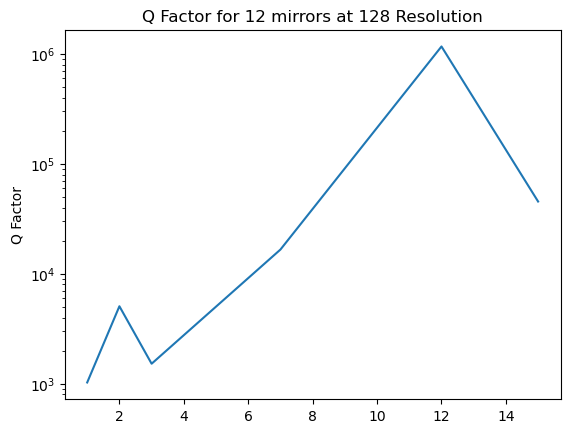

In [13]:
plt.semilogy(data_128_12[data_128_12['Q_Factor'] > 0]['Q_Factor'].head(6))
plt.title('Q Factor for 12 mirrors at 128 Resolution')
plt.ylabel('Q Factor')


Text(0, 0.5, 'Q Factor')

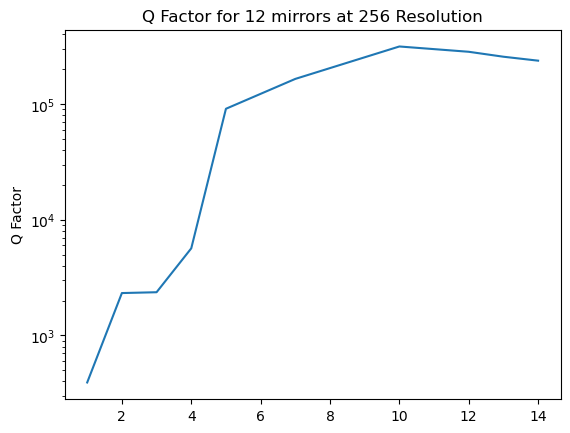

In [7]:
plt.semilogy(data_256_12[data_256_12['Q_Factor'] > 0]['Q_Factor'].head(10))
plt.title('Q Factor for 12 mirrors at 256 Resolution')
plt.ylabel('Q Factor')



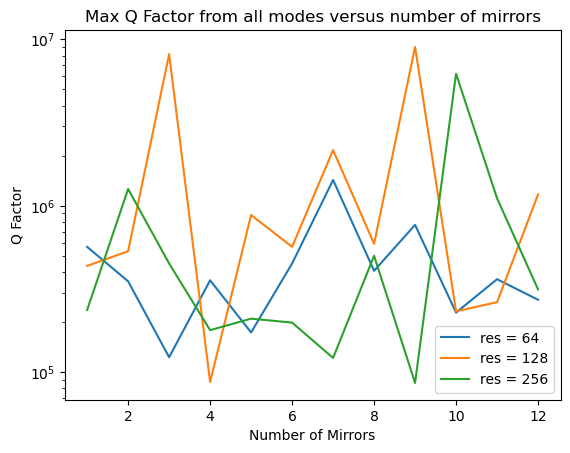

In [11]:
f = plt.figure()
plt.semilogy(mirrors, maxQ64)
plt.semilogy(mirrors, maxQs128)
plt.semilogy(mirrors, maxQs256)
plt.title('Max Q Factor from all modes versus number of mirrors')
plt.xlabel('Number of Mirrors')
plt.ylabel('Q Factor')
plt.legend(['res = 64', 'res = 128', 'res = 256'])